# Notebook 3 — Training
**What this notebook does:** Train Perceiver + cross-attention layers using contrastive loss on pre-extracted embeddings from NB1.

**Runtime:** A100 (Colab Pro+ recommended). Reduce `batch_size` to 8 on T4.

**Data used:**
- Train loop → `msrvtt/train/` + `msvd/train/` manifests
- Val loop   → `msrvtt/val/`   + `msvd/val/`   manifests
- Test set   → never touched here — reserved for NB4

**Requires from Drive:**
```
ariel/
  model.py
  model_config.json
  embeddings/msrvtt/train/manifest.json
  embeddings/msrvtt/val/manifest.json
  embeddings/msvd/train/manifest.json
  embeddings/msvd/val/manifest.json
```
---

In [1]:
!pip install -q transformers accelerate tqdm

## Step 1 · Mount Drive and load model.py + config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os, json
PROJECT = '/content/drive/Shareddrives/DATA 298A/ariel'

sys.path.insert(0, PROJECT)
from model import build_model

with open(f'{PROJECT}/model_config.json') as f:
    MODEL_CONFIG = json.load(f)

os.makedirs(f'{PROJECT}/checkpoints', exist_ok=True)

# Manifest paths — train and val splits only
EMBED_DIR = f'{PROJECT}/embeddings'
TRAIN_MANIFESTS = [
    f'{EMBED_DIR}/msrvtt/train/manifest.json',
    f'{EMBED_DIR}/msvd/train/manifest.json',
]
VAL_MANIFESTS = [
    f'{EMBED_DIR}/msrvtt/val/manifest.json',
    f'{EMBED_DIR}/msvd/val/manifest.json',
]

for p in TRAIN_MANIFESTS + VAL_MANIFESTS:
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  {status}  {p}')

print('\nConfig:', MODEL_CONFIG)

Mounted at /content/drive
  OK  /content/drive/Shareddrives/DATA 298A/ariel/embeddings/msrvtt/train/manifest.json
  OK  /content/drive/Shareddrives/DATA 298A/ariel/embeddings/msvd/train/manifest.json
  OK  /content/drive/Shareddrives/DATA 298A/ariel/embeddings/msrvtt/val/manifest.json
  OK  /content/drive/Shareddrives/DATA 298A/ariel/embeddings/msvd/val/manifest.json

Config: {'llm_name': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0', 'perceiver_latents': 64, 'perceiver_depth': 6, 'xattn_heads': 8, 'xattn_every_n': 2, 'clip_dim': 768, 'proj_dim': 512}


In [3]:
# ── MSVD caption repair ─────────────────────────────────────────────────────
# Run once before training. Fixes MSVD captions which were empty due to
# incorrect tab-separated parsing. Space-separated format is correct.
# Safe to rerun — only updates records that still have empty captions.

import json, os

MSVD_ROOT  = '/content/drive/Shareddrives/DATA 298A/DATA/MSVD'   # ← adjust if needed
EMBED_DIR  = f'{PROJECT}/embeddings'

# Parse AllVideoDescriptions.txt — space separated: video_id caption
captions = {}
with open(f'{MSVD_ROOT}/raw_data/AllVideoDescriptions.txt', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split(' ', 1)
        if len(parts) < 2:
            continue
        vid_id  = parts[0].strip()
        caption = parts[1].strip()
        if caption:
            captions.setdefault(vid_id, []).append(caption)

print(f'Parsed captions for {len(captions)} MSVD video IDs')
sample_key = next(iter(captions))
print(f'Sample: {sample_key} → {captions[sample_key][0]}')

# Update all three MSVD manifest splits
for split in ['train', 'val', 'test']:
    path = f'{EMBED_DIR}/msvd/{split}/manifest.json'
    if not os.path.exists(path):
        print(f'  Skipping {split} — manifest not found')
        continue
    with open(path) as f:
        records = json.load(f)
    fixed = 0
    for rec in records:
        if not rec['captions']:
            caps = captions.get(rec['video_id'], [])
            if caps:
                rec['captions'] = caps
                fixed += 1
    with open(path, 'w') as f:
        json.dump(records, f, indent=2)
    print(f'  {split:5s}: fixed {fixed} / {len(records)} records')

print('Caption repair complete. No .pt files were touched.')

Parsed captions for 1970 MSVD video IDs
Sample: -4wsuPCjDBc_5_15 → a squirrel is eating a peanut in it s shell
  train: fixed 0 / 1200 records
  val  : fixed 0 / 100 records
  test : fixed 0 / 670 records
Caption repair complete. No .pt files were touched.


## Step 2 · Training config

In [4]:
TRAIN_CONFIG = {
    'save_dir'        : f'{PROJECT}/checkpoints',
    'batch_size'      : 64,
    'lr'              : 2e-4,
    'epochs'          : 30,
    'warmup_steps'    : 300,
    'fp16'            : True,
    'max_caption_len' : 64,
}
print(TRAIN_CONFIG)

{'save_dir': '/content/drive/Shareddrives/DATA 298A/ariel/checkpoints', 'batch_size': 64, 'lr': 0.0002, 'epochs': 30, 'warmup_steps': 300, 'fp16': True, 'max_caption_len': 64}


## Step 3 · Dataset — loads from split manifests directly

In [5]:
import json, random, torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


class VideoTextDataset(Dataset):
    """
    Loads pre-extracted CLIP embeddings from manifest files.
    No splitting logic here — manifests already contain the right split.
    Each item: one video embedding + one randomly sampled caption.
    """

    def __init__(self, manifest_paths, tokenizer, max_len=64):
        self.records = []
        for path in manifest_paths:
            if os.path.exists(path):
                with open(path) as f:
                    loaded = json.load(f)
                    self.records += loaded
                print(f'  Loaded {len(loaded):5d} records from {os.path.basename(os.path.dirname(path))}/{os.path.basename(path)}')
            else:
                print(f'  WARNING: manifest not found: {path}')

        self.tokenizer = tokenizer
        self.max_len   = max_len
        print(f'  Total: {len(self.records)} records')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec     = self.records[idx]
        data    = torch.load(rec['embed_path'], map_location='cpu', weights_only=False)
        caption = random.choice(rec['captions']) if rec['captions'] else 'a video'
        toks    = self.tokenizer(
            caption, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {
            'visual_embeds' : data['visual_embeds'],            # (8, 768)
            'input_ids'     : toks['input_ids'].squeeze(0),
            'attention_mask': toks['attention_mask'].squeeze(0),
            'video_id'      : rec['video_id'],
        }


def collate_fn(batch):
    max_T = max(b['visual_embeds'].shape[0] for b in batch)
    vis_padded, masks = [], []
    for b in batch:
        T, D = b['visual_embeds'].shape
        vis_padded.append(F.pad(b['visual_embeds'], (0, 0, 0, max_T - T)))
        masks.append(torch.cat([torch.ones(T), torch.zeros(max_T - T)]))
    return {
        'visual_embeds' : torch.stack(vis_padded),
        'frame_masks'   : torch.stack(masks),
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
    }


print('Dataset class defined.')

Dataset class defined.


## Step 4 · Build model and dataloaders

In [6]:
import torch
from transformers import get_cosine_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model, tokenizer = build_model(MODEL_CONFIG, device)
trainable = [p for p in model.parameters() if p.requires_grad]
trainable_names = {name for name, p in model.named_parameters() if p.requires_grad}
print(f'Trainable params: {sum(p.numel() for p in trainable):,}')

def checkpoint_state_dict(model, trainable_names):
    state = model.state_dict()
    kept = {k: v.detach().cpu() for k, v in state.items() if k in trainable_names and not k.startswith('llm.')}
    print(f'Checkpoint tensors: {len(kept)} (excluding frozen LLM weights)')
    return kept

print('\nLoading train set:')
train_ds = VideoTextDataset(TRAIN_MANIFESTS, tokenizer, TRAIN_CONFIG['max_caption_len'])
print('\nLoading val set:')
val_ds   = VideoTextDataset(VAL_MANIFESTS,   tokenizer, TRAIN_CONFIG['max_caption_len'])

train_loader = DataLoader(train_ds, batch_size=TRAIN_CONFIG['batch_size'],
                          shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=TRAIN_CONFIG['batch_size'],
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0 | hidden=2048 | layers=22
Parameters — total: 1,144,078,337 | trainable: 44,029,953 | frozen: 1,100,048,384
Trainable params: 44,029,953

Loading train set:
  Loaded  8000 records from train/manifest.json
  Loaded  1200 records from train/manifest.json
  Total: 9200 records

Loading val set:
  Loaded  1000 records from val/manifest.json
  Loaded   100 records from val/manifest.json
  Total: 1100 records

Train batches: 144 | Val batches: 18


## Step 5 · Optimiser and scheduler

In [7]:
optimizer   = torch.optim.AdamW(trainable, lr=TRAIN_CONFIG['lr'], weight_decay=0.01)
total_steps = len(train_loader) * TRAIN_CONFIG['epochs']
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=TRAIN_CONFIG['warmup_steps'],
    num_training_steps=total_steps,
)
scaler = torch.amp.GradScaler('cuda', enabled=TRAIN_CONFIG['fp16'])
print(f'Total steps: {total_steps} | Warmup: {TRAIN_CONFIG["warmup_steps"]}')


Total steps: 4320 | Warmup: 300


## Step 6 · Training loop

In [8]:
from tqdm import tqdm

best_val_loss = float('inf')
history = {'train': [], 'val': []}

# Set True ONLY when starting a brand new training run
# Set False when rerunning cells to verify — prevents accidental deletion
FORCE_FRESH_TRAINING = True

import os
old_ckpt = f"{TRAIN_CONFIG['save_dir']}/best_model.pt"
if FORCE_FRESH_TRAINING and os.path.exists(old_ckpt):
    os.remove(old_ckpt)
    print('Removed old checkpoint — starting fresh.')
elif os.path.exists(old_ckpt):
    print('Keeping existing checkpoint. Set FORCE_FRESH_TRAINING=True to delete.')
else:
    print('No existing checkpoint — starting fresh.')

for epoch in range(TRAIN_CONFIG['epochs']):

    # ── Train ──────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1:02d} train')

    for batch in pbar:
        vis   = batch['visual_embeds'].to(device)
        masks = batch['frame_masks'].to(device)
        ids   = batch['input_ids'].to(device)
        amask = batch['attention_mask'].to(device)

        with torch.amp.autocast('cuda', enabled=TRAIN_CONFIG['fp16']):
            loss, _, _ = model(vis, masks, ids, amask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable, 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{scheduler.get_last_lr()[0]:.2e}')

    avg_train = epoch_loss / len(train_loader)
    history['train'].append(avg_train)

    # ── Validate (val split only) ───────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1:02d} val  '):
            vis   = batch['visual_embeds'].to(device)
            masks = batch['frame_masks'].to(device)
            ids   = batch['input_ids'].to(device)
            amask = batch['attention_mask'].to(device)
            with torch.amp.autocast('cuda', enabled=TRAIN_CONFIG['fp16']):
                loss, _, _ = model(vis, masks, ids, amask)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    history['val'].append(avg_val)
    print(f'Epoch {epoch+1:02d} | train {avg_train:.4f} | val {avg_val:.4f}')

    # ── Save best checkpoint when val improves ──────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        ckpt_path = f"{TRAIN_CONFIG['save_dir']}/best_model.pt"
        filtered_state = checkpoint_state_dict(model, trainable_names)
        torch.save({
            'epoch'        : epoch + 1,
            'model_state'  : filtered_state,
            'val_loss'     : avg_val,
            'model_config' : MODEL_CONFIG,
        }, ckpt_path)
        size_mb = os.path.getsize(ckpt_path) / (1024 ** 2)
        print(f'  Checkpoint saved (epoch={epoch + 1}, val={avg_val:.4f}, size={size_mb:.1f} MB)')

print('Training complete. Move to NB4 for evaluation on the test set.')


No existing checkpoint — starting fresh.


Epoch 01 val  : 100%|██████████| 18/18 [04:57<00:00, 16.50s/it]


Epoch 01 | train 2.7426 | val 1.9106
Checkpoint tensors: 92 (excluding frozen LLM weights)
  Checkpoint saved (epoch=1, val=1.9106, size=168.0 MB)


Epoch 02 val  : 100%|██████████| 18/18 [00:11<00:00,  1.57it/s]


Epoch 02 | train 1.6944 | val 1.6477
Checkpoint tensors: 92 (excluding frozen LLM weights)
  Checkpoint saved (epoch=2, val=1.6477, size=168.0 MB)


...

Epoch 28 | train 0.5101 | val 1.0351


Epoch 29 val  : 100%|██████████| 18/18 [00:11<00:00,  1.57it/s]


Epoch 29 | train 0.4877 | val 1.0125


Epoch 30 val  : 100%|██████████| 18/18 [00:11<00:00,  1.58it/s]

Epoch 30 | train 0.4969 | val 0.9658
Training complete. Move to NB4 for evaluation on the test set.


In [9]:
import os, time, torch

ckpt_path = f'{PROJECT}/checkpoints/best_model.pt'
st = os.stat(ckpt_path)
ckpt = torch.load(ckpt_path, map_location='cpu')
print(f'Path     : {ckpt_path}')
print(f'Size MB  : {st.st_size / (1024 ** 2):.1f}')
print(f'Modified : {time.ctime(st.st_mtime)}')
print(f'Epoch    : {ckpt["epoch"]}')
print(f'Val loss : {ckpt["val_loss"]}')
print(f'Config   : {ckpt["model_config"]}')
llm_keys = [k for k in ckpt['model_state'] if k.startswith('llm.')]
print(f'LLM keys saved: {len(llm_keys)}')


Path     : /content/drive/Shareddrives/DATA 298A/ariel/checkpoints/best_model.pt
Size MB  : 168.0
Modified : Fri May  8 07:22:04 2026
Epoch    : 23
Val loss : 0.9626838763554891
Config   : {'llm_name': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0', 'perceiver_latents': 64, 'perceiver_depth': 6, 'xattn_heads': 8, 'xattn_every_n': 2, 'clip_dim': 768, 'proj_dim': 512}
LLM keys saved: 0


## Step 7 · Plot training curves

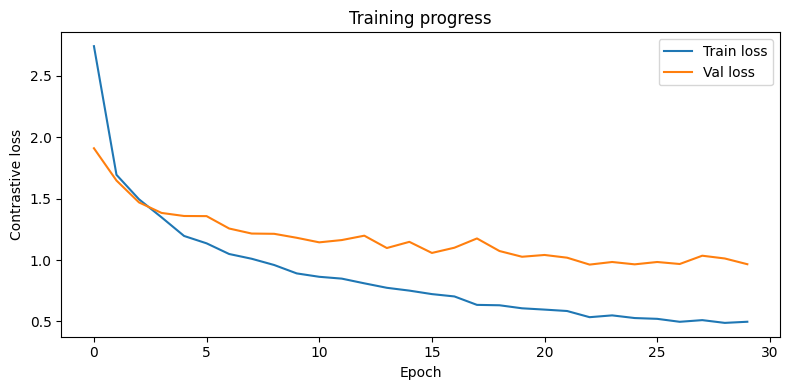

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['train'], label='Train loss')
plt.plot(history['val'],   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Contrastive loss')
plt.title('Training progress'); plt.legend(); plt.tight_layout()
plt.savefig(f"{TRAIN_CONFIG['save_dir']}/training_curve.png", dpi=120)
plt.show()